# 03 · Modèles texte

**Ce que fait ce notebook.** Il mesure quatre façons de classer un article à partir de sa seule
description, **à protocole constant** : même découpe, même jeu de test, mêmes métriques.

Deux familles s'opposent :

| Famille | Principe | Ce qu'on attend |
|---|---|---|
| **Lexicale** — TF-IDF | poids d'un terme = fréquence × rareté | forte si le vocabulaire discrimine |
| **Encodeur figé** — BERT, ModernBERT | vecteur contextuel, moyenne des tokens | forte si le sens compte plus que les mots |

> **Une précaution qui change la lecture de tout ce notebook.** Les encodeurs sont utilisés **figés**,
> sans réglage fin. Un modèle de langage masqué n'a jamais été entraîné à produire un bon vecteur de
> phrase par moyenne de ses tokens — c'est précisément la raison d'être des modèles d'embedding
> dédiés. Ce qui est mesuré ici est donc **une représentation, pas la capacité d'un modèle.**

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

SURFACE, ENCRE, ENCRE_2 = "#fcfcfb", "#0b0b0b", "#52514e"
BLEU, BLEU_CLAIR, BLEU_FONCE, GRILLE = "#2a78d6", "#cde2fb", "#0d366b", "#e0dfdb"
VERT, ROUGE = "#0ca30c", "#d03b3b"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "font.size": 11,
        "text.color": ENCRE,
        "axes.labelcolor": ENCRE_2,
        "axes.edgecolor": GRILLE,
        "xtick.color": ENCRE_2,
        "ytick.color": ENCRE_2,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

from src.evaluate import SEUIL_F1_METIER
from src.pipeline import LABEL_COL, SEED, TEXT_COL, load, split

df = load()
train, val, test = split(df)
CATEGORIES = sorted(df[LABEL_COL].unique())
print(f"train {len(train)} · val {len(val)} · test {len(test)}")
print(f"seuil métier : F1 macro >= {SEUIL_F1_METIER:.2f}, fixé avant toute mesure")

train 735 · val 157 · test 158
seuil métier : F1 macro >= 0.90, fixé avant toute mesure


In [2]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder().fit(df[LABEL_COL])
y_tr, y_te = enc.transform(train[LABEL_COL]), enc.transform(test[LABEL_COL])
txt_tr, txt_te = train[TEXT_COL].tolist(), test[TEXT_COL].tolist()

## 1 · La chaîne TF-IDF, suivie sur un article réel

Avant les scores, il faut voir ce que le modèle reçoit. On prend un article du jeu de test et on le
suit d'un bout à l'autre de la transformation.

In [3]:
from src.text import vectoriseur

vec = vectoriseur()
X_tr = vec.fit_transform(txt_tr)  # ajusté sur l'entraînement UNIQUEMENT
X_te = vec.transform(txt_te)
termes = np.array(vec.get_feature_names_out())
print(f"vocabulaire : {len(termes)} termes · matrice d'entraînement {X_tr.shape}")
print(f"densité : {X_tr.nnz / (X_tr.shape[0] * X_tr.shape[1]):.4%} — la matrice est très creuse")

vocabulaire : 4532 termes · matrice d'entraînement (735, 4532)
densité : 1.1846% — la matrice est très creuse


In [4]:
i = 0
brut = txt_te[i]
print("1 · DESCRIPTION BRUTE")
print(f"    {len(brut.split())} mots")
print(f"    {brut[:180]}…\n")

jetons = vec.build_analyzer()(brut)
print("2 · NORMALISATION ET JETONS")
print(f"    {len(jetons)} jetons retenus")
print(f"    {' · '.join(jetons[:12])}…\n")

v = X_te[i].toarray().ravel()
top = np.argsort(-v)[:8]
print("3 · PONDÉRATION TF-IDF")
print(f"    {int((v > 0).sum())} termes non nuls sur {len(termes)}")
for j in top:
    print(f"      {termes[j]:26s} {v[j]:.3f}")
print(f"\n    catégorie réelle : {test[LABEL_COL].iloc[i]}")

1 · DESCRIPTION BRUTE
    55 mots
    Maxima 07034LMLI Attivo Analog Watch  - For Women - Buy Maxima 07034LMLI Attivo Analog Watch  - For Women  07034LMLI Online at Rs.641 in India Only at Flipkart.com. Brass Case, Buc…

2 · NORMALISATION ET JETONS
    85 jetons retenus
    maxima · 07034lmli · attivo · analog · watch · women · buy · maxima · 07034lmli · attivo · analog · watch…

3 · PONDÉRATION TF-IDF
    61 termes non nuls sur 4532
      attivo                     0.332
      attivo analog              0.332
      maxima                     0.250
      watch women                0.206
      dial white                 0.196
      rectangular dial           0.196
      case buckle                0.187
      women                      0.182

    catégorie réelle : Watches


Les termes de plus fort poids sont exactement ceux qu'un humain retiendrait. C'est le premier
argument en faveur du TF-IDF sur ce type de texte : **il est lisible terme à terme**, ce qu'aucun
encodeur ne permet.

## 2 · Deux classifieurs sur la représentation lexicale

`XGBoost` — arbres boostés, robuste sans réglage. `MLP` — réseau dense, et ses probabilités de sortie
sont directement exploitables comme **score de confiance**, ce qui servira au notebook 05.

In [5]:
import time

from sklearn.neural_network import MLPClassifier

from src.evaluate import mesurer

resultats, probas = [], {}


def evaluer(nom, entraine, predire, empreinte_mo, t_entrainement):
    """Mesure une approche. L'inférence est chronométrée DE BOUT EN BOUT."""
    t0 = time.perf_counter()
    pred = predire()
    ms = (time.perf_counter() - t0) * 1000 / len(y_te)
    ligne = mesurer(nom, y_te, pred, CATEGORIES, t_entrainement, ms, empreinte_mo)
    resultats.append(ligne)
    print(
        f"{nom:28s} F1 {ligne['F1 macro']:.4f} · min {ligne['F1 classe min']:.3f}"
        f" · {t_entrainement:6.2f} s · {ms:6.2f} ms · seuil {ligne['Seuil 0,90']}"
    )
    return ligne


import xgboost as xgb

clf = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.2,
    subsample=0.9,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
)
t0 = time.perf_counter()
clf.fit(X_tr, y_tr)
t_xgb = time.perf_counter() - t0
evaluer("TF-IDF + XGBoost", clf, lambda: clf.predict(vec.transform(txt_te)), 2.6, t_xgb)

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64), max_iter=300, early_stopping=True, random_state=SEED
)
t0 = time.perf_counter()
mlp.fit(X_tr, y_tr)
t_mlp = time.perf_counter() - t0
evaluer("TF-IDF + MLP", mlp, lambda: mlp.predict(vec.transform(txt_te)), 14.3, t_mlp)
probas["TF-IDF + MLP"] = mlp.predict_proba(vec.transform(txt_te))

TF-IDF + XGBoost             F1 0.9234 · min 0.837 ·   4.55 s ·   0.08 ms · seuil oui


TF-IDF + MLP                 F1 0.9427 · min 0.870 ·   0.46 s ·   0.06 ms · seuil oui


**Le chronomètre englobe la vectorisation.** C'est un détail qui n'en est pas un : mesurer
seulement `predict()` sur une matrice déjà calculée donne des temps flatteurs et faux. En production,
un article arrive sous forme de texte, pas de vecteur.

## 3 · Les encodeurs pré-entraînés, figés

Même tête linéaire, même découpe, seule la représentation change. C'est une **ablation**, pas un
concours : on isole l'effet de la représentation.

In [6]:
from sklearn.linear_model import LogisticRegression

from src.text import ENCODEURS, charger_encodeur, empreinte_mo, encoder

for nom, model_id in ENCODEURS.items():
    tok, mdl, device = charger_encodeur(model_id)
    mo = empreinte_mo(mdl)

    t0 = time.perf_counter()
    E_tr = encoder(txt_tr, tok, mdl, device)
    tete = LogisticRegression(max_iter=2000, random_state=SEED)
    tete.fit(E_tr, y_tr)
    t = time.perf_counter() - t0

    evaluer(
        nom, tete, lambda t=tete, k=tok, m=mdl, d=device: t.predict(encoder(txt_te, k, m, d)), mo, t
    )
    del mdl

/Users/trikwi/P15/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6182.39it/s]


[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT figé (2018)             F1 0.9243 · min 0.870 ·  16.71 s ·  22.23 ms · seuil oui


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 134/134 [00:00<00:00, 6122.07it/s]


[transformers] ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ModernBERT figé (2024)       F1 0.8854 · min 0.800 ·  29.16 s ·  38.91 ms · seuil non


In [7]:
tableau = pd.DataFrame([{k: v for k, v in r.items() if k != "_par_classe"} for r in resultats])
tableau.sort_values("F1 macro", ascending=False)

,Modèle,F1 macro,Accuracy,F1 classe min,Entraînement (s),Inférence (ms/article),Empreinte (Mo),"Seuil 0,90"
1,TF-IDF + MLP,0.9427,0.9430,0.8696,0.46,0.06,14.3,oui
2,BERT figé (2018),0.9243,0.9241,0.8696,16.71,22.23,437.9,oui
0,TF-IDF + XGBoost,0.9234,0.9241,0.8372,4.55,0.08,2.6,oui
3,ModernBERT figé (2024),0.8854,0.8861,0.8000,29.16,38.91,596.1,non


**Le résultat est net, et contre-intuitif.** La représentation lexicale bat les deux encodeurs
pré-entraînés — sur la performance **et** sur tous les axes de coût à la fois. ModernBERT, le plus
récent et le plus lourd, est le seul à ne pas franchir le seuil métier.

Deux explications, à énoncer plutôt qu'à laisser deviner :

1. **La tâche est lexicalement séparable.** Le notebook 02 l'avait montré : le vocabulaire d'une fiche
   produit est très discriminant. C'est le terrain de jeu du TF-IDF.
2. **La moyenne des tokens est une mauvaise représentation de phrase.** Ces modèles ont été entraînés
   à prédire des mots masqués, pas à produire un vecteur de document. Un réglage fin renverserait
   probablement le classement — il n'a pas été fait, et c'est écrit comme tel.

La conclusion défendable est donc étroite : *à protocole constant, sur cette tâche et à ce volume,
une représentation lexicale bat les encodeurs de texte figés.* Rien de plus.

## 4 · Où sont les erreurs ?

La F1 macro est une moyenne : elle ne dit pas *quelle* catégorie décroche. Seule la lecture par
classe le dit.

In [8]:
par_classe = pd.DataFrame({r["Modèle"]: r["_par_classe"] for r in resultats})
par_classe = par_classe.loc[par_classe.mean(axis=1).sort_values().index]
par_classe.style.background_gradient(cmap="Blues", axis=None).format("{:.3f}")

,TF-IDF + XGBoost,TF-IDF + MLP,BERT figé (2018),ModernBERT figé (2024)
Home Decor & Festive Needs,0.864,0.870,0.870,0.800
Baby Care,0.837,0.905,0.884,0.829
Kitchen & Dining,0.913,0.933,0.936,0.864
Home Furnishing,0.920,0.958,0.894,0.880
Beauty and Personal Care,0.952,0.977,0.955,0.870
Watches,0.978,0.978,0.955,0.978
Computers,1.000,0.979,0.978,0.978


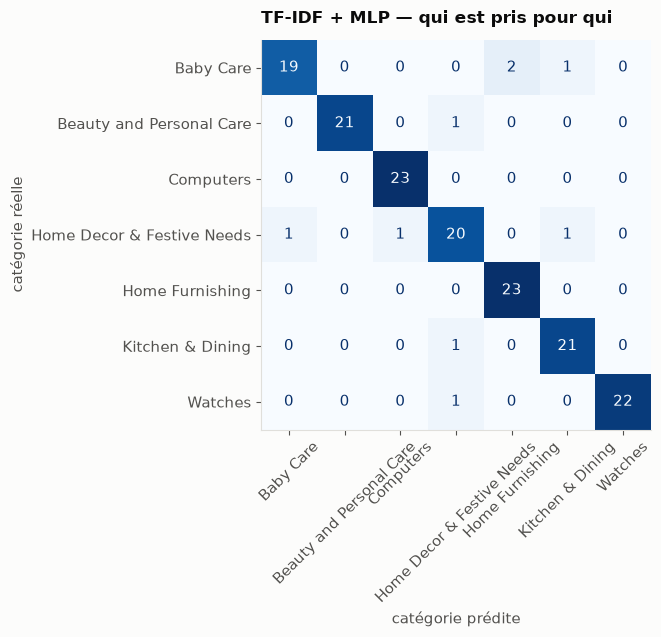

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

pred_mlp = mlp.predict(X_te)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ConfusionMatrixDisplay.from_predictions(
    y_te,
    pred_mlp,
    display_labels=CATEGORIES,
    cmap="Blues",
    colorbar=False,
    xticks_rotation=45,
    ax=ax,
    values_format="d",
)
ax.set_title(
    "TF-IDF + MLP — qui est pris pour qui", fontsize=12, fontweight="bold", loc="left", pad=12
)
ax.set_xlabel("catégorie prédite")
ax.set_ylabel("catégorie réelle")
plt.tight_layout()
plt.show()

**L'hypothèse du notebook 02 est confirmée.** Les deux catégories les plus faibles sont *Home
Decor & Festive Needs* et *Baby Care*, et la matrice de confusion montre qu'elles se mélangent avec
*Kitchen & Dining* et *Home Furnishing* — les quatre catégories domestiques qui se chevauchaient
déjà dans la projection.

La raison est intelligible : un vase, un plat et un rideau se décrivent avec le même vocabulaire —
matière, dimensions, couleur. **Le texte a atteint sa limite ; il faut une autre information.**

## Ce qui sort de ce notebook

| | |
|---|---|
| Meilleur modèle texte | TF-IDF + MLP — F1 macro 0,943 |
| Coût | 0,5 s d'entraînement, 0,06 ms par article, 14 Mo |
| Les encodeurs figés | battus sur tous les axes, ModernBERT sous le seuil |
| Limite atteinte | les 4 catégories domestiques, F1 minimale 0,870 |
| Ce qui n'est pas démontré | qu'un encodeur **réglé finement** ne gagnerait pas |

→ Notebook suivant : **04 · Modèle image**, pour aller chercher l'information que le texte n'a pas.